# Confidence intervals — TES (Al), heavy mediator (F_DM = 1), m_DM = 1 GeV

Point-wise profile confidence bands of the recovered flux x(v_min), one
subsection per halo model. Method and conventions:
[`quantum_sensor.statistics.find_confidence_band`](../src/quantum_sensor/statistics.py)
(neutrinoAnalysis construction: observed profile Δχ² vs an MC-calibrated
cutoff; Poisson pseudo-experiments; CLARABEL solver, thread-parallel).

- Configuration: `material='Al', q='0', mass='3', nbins=5`, background `none`
- Outputs per model: `results/TES/bkg-none/<config>/` —
  `band/band_idx*.json` (primary, one per point), `flux_profile_band.csv`
  (summary), `flux_profile_band.pdf` (figure)
- **Each `run_model` cell takes ~30–60 min** (production MC settings).
  Already computed? Use `show_saved` in §Saved results instead.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from quantum_sensor import (DarkMatterQuantumAnalysis, RunConfig,
                            pointwise_band, load_pointwise_band,
                            band_table, save_band_products)
from quantum_sensor.plotting import plot_flux_with_pointwise_bands, run_dir

MATERIAL, Q, MASS, NBINS = 'Al', '0', '3', 5
LEVELS = (0.68, 0.954)                                   # 1 sigma, 2 sigma
MC = dict(num_pseudo=50, n_pseudo_edge=500, rel_tol=0.02)  # production settings
N_INDICES = 30


def build(eta='Halo', disk_fraction=None):
    cfg = RunConfig(material=MATERIAL, q=Q, mass=MASS, nbins=NBINS,
                    eta=eta, disk_fraction=disk_fraction, background='none')
    a = DarkMatterQuantumAnalysis(cfg)
    a.optimize()
    return a


def run_model(eta='Halo', disk_fraction=None):
    """Compute, save and display the band for one halo model (heavy)."""
    a = build(eta, disk_fraction)
    print(f'{a.config}')
    print(f'counts per bin: {np.array2string(a.observed, precision=1)}')
    bands = pointwise_band(a, n_indices=N_INDICES, levels=LEVELS, **MC)
    save_band_products(a, bands)
    display(band_table(bands))
    return a, bands


def show_saved(eta='Halo', disk_fraction=None):
    """Reload a saved band (band/*.json) — no recomputation."""
    a = build(eta, disk_fraction)
    bands = load_pointwise_band(run_dir(a))
    print(f'{len(bands)} points from {run_dir(a) / "band"}')
    display(band_table(bands))
    plot_flux_with_pointwise_bands(a, bands, save=False)
    return a, bands


## 1. Standard halo (SHM)


RunConfig(material='Al', q='0', mass='3', nbins=5, eta='Halo', disk_fraction=None, background='none', run=None)
counts per bin: [15.8 32.4 47.6 63.8 79.8]
[1/22] idx 0 (v=5 km/s)  best 4.18e-28 cm^-1  1sigma [3.9e-28, 4.79e-27]  2sigma [3.66e-28, 9.5e-27]  (28 evals)
[2/22] idx 1 (v=5 km/s)  best 4.18e-28 cm^-1  1sigma [3.95e-28, 1.52e-27]  2sigma [3.66e-28, 3.05e-27]  (27 evals)
[3/22] idx 2 (v=6 km/s)  best 4.18e-28 cm^-1  1sigma [3.95e-28, 8.34e-28]  2sigma [3.66e-28, 1.55e-27]  (24 evals)
[4/22] idx 3 (v=7 km/s)  best 4.18e-28 cm^-1  1sigma [3.95e-28, 6.41e-28]  2sigma [3.66e-28, 1.03e-27]  (24 evals)
[5/22] idx 4 (v=8 km/s)  best 4.18e-28 cm^-1  1sigma [3.95e-28, 6.16e-28]  2sigma [3.66e-28, 8.67e-28]  (22 evals)
[6/22] idx 5 (v=9 km/s)  best 4.18e-28 cm^-1  1sigma [3.95e-28, 6.18e-28]  2sigma [3.66e-28, 8.69e-28]  (24 evals)
[7/22] idx 6 (v=9 km/s)  best 4.18e-28 cm^-1  1sigma [3.95e-28, 5.93e-28]  2sigma [3.66e-28, 7.93e-28]  (22 evals)
[8/22] idx 8 (v=11 km/s)  best 4.18e-28 cm

,index,vmin [km/s],best fit [cm^-1],lo 1sigma [cm^-1],hi 1sigma [cm^-1],lo 2sigma [cm^-1],hi 2sigma [cm^-1],-68%,+68%,evals
0,0,4.6,4.182303e-28,3.900844e-28,4.794278e-27,3.661376e-28,9.503361e-27,-7%,+1046%,28
1,1,5.4,4.182303e-28,3.950585e-28,1.520660e-27,3.661376e-28,3.052734e-27,-6%,+264%,27
2,2,6.2,4.182303e-28,3.950585e-28,8.343143e-28,3.661376e-28,1.552278e-27,-6%,+99%,24
3,3,7.0,4.182303e-28,3.950585e-28,6.414405e-28,3.661376e-28,1.031605e-27,-6%,+53%,24
4,4,7.8,4.182303e-28,3.950585e-28,6.155470e-28,3.661376e-28,8.666390e-28,-6%,+47%,22
5,5,8.6,4.182303e-28,3.950585e-28,6.175155e-28,3.661376e-28,8.694104e-28,-6%,+48%,24
6,6,9.4,4.182303e-28,3.950585e-28,5.925877e-28,3.661376e-28,7.930823e-28,-6%,+42%,22
7,8,11.0,4.182303e-28,3.900844e-28,5.633020e-28,3.661376e-28,7.166308e-28,-7%,+35%,22
8,9,11.8,4.182303e-28,3.900844e-28,5.492064e-28,3.569756e-28,6.812147e-28,-7%,+31%,22
9,11,13.4,4.182303e-28,3.851729e-28,5.154912e-28,3.569756e-28,6.393958e-28,-8%,+23%,22


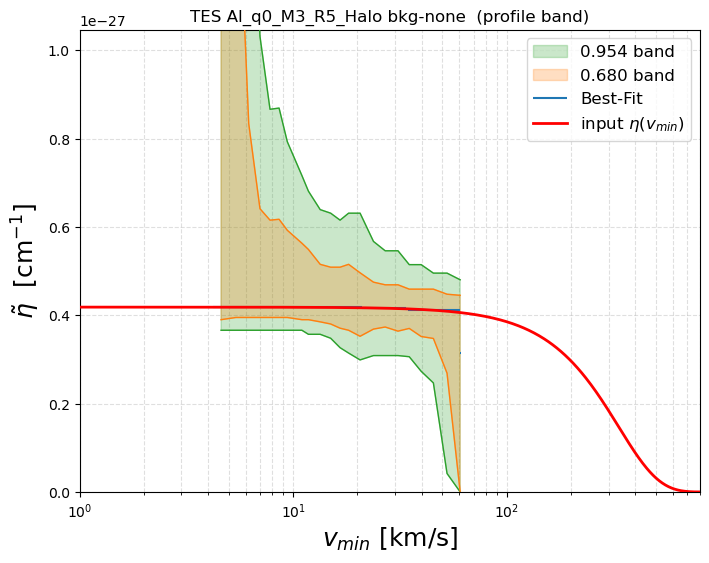

In [2]:
a_halo, b_halo = run_model(eta='Halo')


## 2. Pure dark disk


In [ ]:
a_disk, b_disk = run_model(eta='Disk')


## 3. Halo + dark-disk mixtures

The fit eta is `(1-p)·Halo + p·Disk` with the same total local DM density.


RunConfig(material='Al', q='0', mass='3', nbins=5, eta='Halo', disk_fraction=0.05, background='none', run=None)
counts per bin: [17.2 35.2 51.6 69.  86. ]
[1/22] idx 0 (v=5 km/s)  best 4.55e-28 cm^-1  1sigma [4.19e-28, 4.88e-27]  2sigma [3.93e-28, 1.08e-26]  (33 evals)
[2/22] idx 1 (v=5 km/s)  best 4.55e-28 cm^-1  1sigma [4.29e-28, 1.46e-27]  2sigma [3.98e-28, 3.43e-27]  (27 evals)
[3/22] idx 2 (v=6 km/s)  best 4.55e-28 cm^-1  1sigma [4.29e-28, 9.3e-28]  2sigma [3.98e-28, 1.65e-27]  (24 evals)
[4/22] idx 3 (v=7 km/s)  best 4.55e-28 cm^-1  1sigma [4.29e-28, 7.04e-28]  2sigma [3.98e-28, 1.02e-27]  (21 evals)
[5/22] idx 4 (v=8 km/s)  best 4.55e-28 cm^-1  1sigma [4.29e-28, 6.52e-28]  2sigma [3.98e-28, 9.54e-28]  (22 evals)
[6/22] idx 5 (v=9 km/s)  best 4.55e-28 cm^-1  1sigma [4.24e-28, 6.61e-28]  2sigma [3.98e-28, 9.07e-28]  (22 evals)
[7/22] idx 6 (v=9 km/s)  best 4.55e-28 cm^-1  1sigma [4.24e-28, 6.44e-28]  2sigma [3.93e-28, 8.51e-28]  (22 evals)
[8/22] idx 8 (v=11 km/s)  best 4.55e-28 c

,index,vmin [km/s],best fit [cm^-1],lo 1sigma [cm^-1],hi 1sigma [cm^-1],lo 2sigma [cm^-1],hi 2sigma [cm^-1],-68%,+68%,evals
0,0,4.6,4.546439e-28,4.187083e-28,4.880174e-27,3.930043e-28,1.084214e-26,-8%,+973%,33
1,1,5.4,4.546439e-28,4.294546e-28,1.456329e-27,3.980156e-28,3.425327e-27,-6%,+220%,27
2,2,6.2,4.546439e-28,4.294546e-28,9.302319e-28,3.980156e-28,1.645203e-27,-6%,+105%,24
3,3,7.0,4.546439e-28,4.294546e-28,7.039284e-28,3.980156e-28,1.016509e-27,-6%,+55%,21
4,4,7.8,4.546439e-28,4.294546e-28,6.523961e-28,3.980156e-28,9.541067e-28,-6%,+43%,22
5,5,8.6,4.546439e-28,4.240474e-28,6.607151e-28,3.980156e-28,9.069545e-28,-7%,+45%,22
6,6,9.4,4.546439e-28,4.240474e-28,6.441819e-28,3.930043e-28,8.512777e-28,-7%,+42%,22
7,8,11.0,4.546439e-28,4.240474e-28,6.046364e-28,3.880560e-28,7.692162e-28,-7%,+33%,22
8,9,11.8,4.546439e-28,4.187083e-28,5.895064e-28,3.831701e-28,7.405253e-28,-8%,+30%,22
9,11,13.4,4.546439e-28,4.187083e-28,5.603729e-28,3.831701e-28,6.950653e-28,-8%,+23%,22


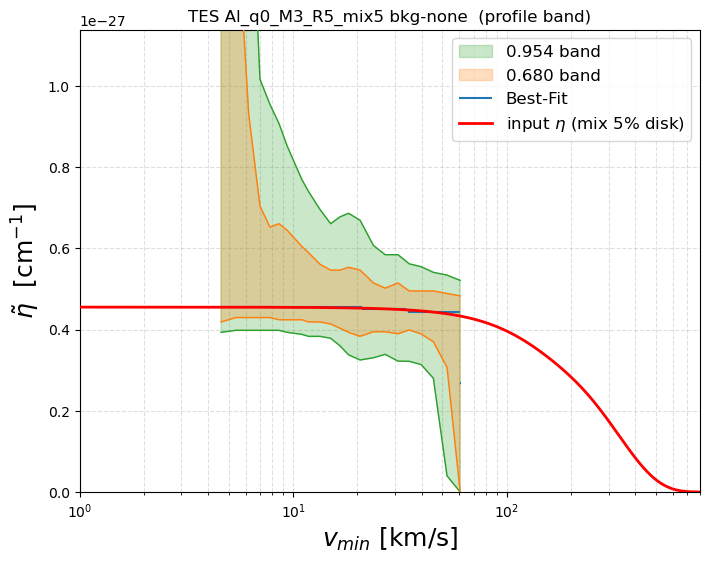

In [3]:
a_mix5, b_mix5 = run_model(disk_fraction=0.05)    # 5% disk


RunConfig(material='Al', q='0', mass='3', nbins=5, eta='Halo', disk_fraction=0.25, background='none', run=None)
counts per bin: [ 22.7  46.3  67.6  89.8 110.8]
[1/22] idx 0 (v=5 km/s)  best 6e-28 cm^-1  1sigma [5.53e-28, 5.19e-27]  2sigma [5.19e-28, 1.02e-26]  (30 evals)
[2/22] idx 1 (v=5 km/s)  best 6e-28 cm^-1  1sigma [5.6e-28, 1.9e-27]  2sigma [5.26e-28, 3.83e-27]  (28 evals)
[3/22] idx 2 (v=6 km/s)  best 6e-28 cm^-1  1sigma [5.6e-28, 1.14e-27]  2sigma [5.26e-28, 2.04e-27]  (24 evals)
[4/22] idx 3 (v=7 km/s)  best 6e-28 cm^-1  1sigma [5.6e-28, 8.61e-28]  2sigma [5.26e-28, 1.34e-27]  (22 evals)
[5/22] idx 4 (v=8 km/s)  best 6e-28 cm^-1  1sigma [5.6e-28, 8.37e-28]  2sigma [5.26e-28, 1.16e-27]  (24 evals)
[6/22] idx 5 (v=9 km/s)  best 6e-28 cm^-1  1sigma [5.6e-28, 8.51e-28]  2sigma [5.26e-28, 1.12e-27]  (22 evals)
[7/22] idx 6 (v=9 km/s)  best 6e-28 cm^-1  1sigma [5.53e-28, 8.29e-28]  2sigma [5.26e-28, 1.04e-27]  (22 evals)
[8/22] idx 8 (v=11 km/s)  best 6e-28 cm^-1  1sigma [5.53e-28, 

,index,vmin [km/s],best fit [cm^-1],lo 1sigma [cm^-1],hi 1sigma [cm^-1],lo 2sigma [cm^-1],hi 2sigma [cm^-1],-68%,+68%,evals
0,0,4.6,6.002982e-28,5.528499e-28,5.186690e-27,5.189111e-28,1.020011e-26,-8%,+764%,30
1,1,5.4,6.002982e-28,5.598995e-28,1.895704e-27,5.255280e-28,3.829823e-27,-7%,+216%,28
2,2,6.2,6.002982e-28,5.598995e-28,1.138334e-27,5.255280e-28,2.038924e-27,-7%,+90%,24
3,3,7.0,6.002982e-28,5.598995e-28,8.614043e-28,5.255280e-28,1.342168e-27,-7%,+43%,22
4,4,7.8,6.002982e-28,5.598995e-28,8.372141e-28,5.255280e-28,1.156536e-27,-7%,+39%,24
5,5,8.6,6.002982e-28,5.598995e-28,8.505585e-28,5.255280e-28,1.124002e-27,-7%,+42%,22
6,6,9.4,6.002982e-28,5.528499e-28,8.292748e-28,5.255280e-28,1.041717e-27,-8%,+38%,22
7,8,11.0,6.002982e-28,5.528499e-28,7.783667e-28,5.189111e-28,9.777674e-28,-8%,+30%,22
8,9,11.8,6.002982e-28,5.528499e-28,7.685664e-28,5.123776e-28,9.177435e-28,-8%,+28%,22
9,11,13.4,6.002982e-28,5.458890e-28,7.305837e-28,4.995563e-28,8.835126e-28,-9%,+22%,20


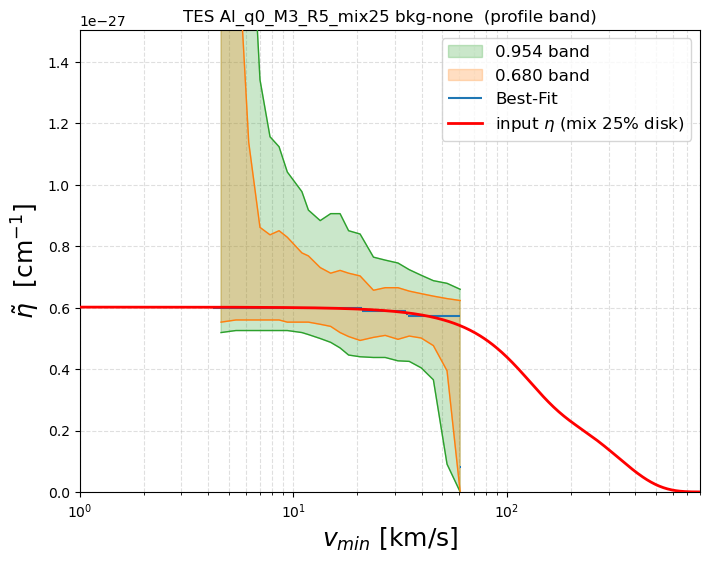

In [4]:
a_mix25, b_mix25 = run_model(disk_fraction=0.25)  # 25% disk


## 4. Earth-bound population (Halo + Bound)

The bound population sits on top of the full SHM halo; it is nonzero only
below v_esc = 11.2 km/s, which only the 1 GeV window reaches.


RunConfig(material='Al', q='0', mass='3', nbins=5, eta='Bound', disk_fraction=None, background='none', run=None)
counts per bin: [2.4e+14 2.4e+11 1.4e+08 2.1e+04 8.0e+01]
[1/22] idx 0 (v=5 km/s)  best 3.18e-14 cm^-1  1sigma [3.16e-14, 3.2e-14]  2sigma [3.16e-14, 3.2e-14]  (13 evals)
[2/22] idx 1 (v=5 km/s)  best 3.18e-14 cm^-1  1sigma [3.16e-14, 3.2e-14]  2sigma [3.16e-14, 3.2e-14]  (13 evals)
[3/22] idx 2 (v=6 km/s)  best 3.18e-14 cm^-1  1sigma [3.16e-14, 3.2e-14]  2sigma [3.16e-14, 3.2e-14]  (13 evals)
[4/22] idx 3 (v=7 km/s)  best 1.52e-15 cm^-1  1sigma [1.51e-15, 1.53e-15]  2sigma [1.51e-15, 1.53e-15]  (13 evals)
[5/22] idx 4 (v=8 km/s)  best 2.05e-20 cm^-1  1sigma [2.04e-20, 2.06e-20]  2sigma [2.04e-20, 2.06e-20]  (13 evals)
[6/22] idx 5 (v=9 km/s)  best 2.05e-20 cm^-1  1sigma [2.04e-20, 2.06e-20]  2sigma [2.04e-20, 2.06e-20]  (13 evals)
[7/22] idx 6 (v=9 km/s)  best 2.05e-20 cm^-1  1sigma [2.04e-20, 2.06e-20]  2sigma [2.04e-20, 2.06e-20]  (13 evals)
[8/22] idx 8 (v=11 km/s)  best

,index,vmin [km/s],best fit [cm^-1],lo 1sigma [cm^-1],hi 1sigma [cm^-1],lo 2sigma [cm^-1],hi 2sigma [cm^-1],-68%,+68%,evals
0,0,4.6,3.180024e-14,3.160005e-14,3.200299e-14,3.160005e-14,3.200299e-14,-1%,+1%,13
1,1,5.4,3.180024e-14,3.160005e-14,3.200299e-14,3.160005e-14,3.200299e-14,-1%,+1%,13
2,2,6.2,3.180024e-14,3.160005e-14,3.200299e-14,3.160005e-14,3.200299e-14,-1%,+1%,13
3,3,7.0,1.517003e-15,1.507453e-15,1.526675e-15,1.507453e-15,1.526675e-15,-1%,+1%,13
4,4,7.8,2.049083e-20,2.036183e-20,2.062148e-20,2.036183e-20,2.062148e-20,-1%,+1%,13
5,5,8.6,2.049083e-20,2.036183e-20,2.062148e-20,2.036183e-20,2.062148e-20,-1%,+1%,13
6,6,9.4,2.049083e-20,2.036183e-20,2.062148e-20,2.036183e-20,2.062148e-20,-1%,+1%,13
7,8,11.0,6.347448e-23,6.307489e-23,6.387918e-23,6.307489e-23,6.387918e-23,-1%,+1%,13
8,9,11.8,4.124784e-28,4.098817e-28,4.151083e-28,4.098817e-28,4.151083e-28,-1%,+1%,13
9,11,13.4,4.124784e-28,4.098817e-28,4.151083e-28,4.098817e-28,4.151083e-28,-1%,+1%,13


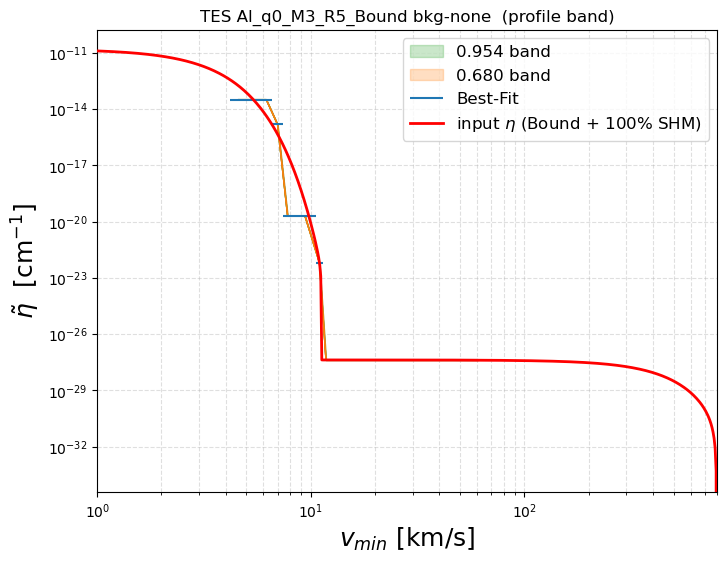

In [5]:
a_bound, b_bound = run_model(eta='Bound')


## Saved results (no recomputation)

Reload any model computed above (or in a previous session).


26 points from /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M3_R5_Halo/band


,index,vmin [km/s],best fit [cm^-1],lo 1sigma [cm^-1],hi 1sigma [cm^-1],lo 2sigma [cm^-1],hi 2sigma [cm^-1],-68%,+68%,evals
0,0,4.6,4.182303e-28,3.900844e-28,4.794278e-27,3.661376e-28,9.503361e-27,-7%,+1046%,28
1,1,5.4,4.182303e-28,3.950585e-28,1.520660e-27,3.661376e-28,3.052734e-27,-6%,+264%,27
2,2,6.2,4.182303e-28,3.950585e-28,8.343143e-28,3.661376e-28,1.552278e-27,-6%,+99%,24
3,3,7.0,4.182303e-28,3.950585e-28,6.414405e-28,3.661376e-28,1.031605e-27,-6%,+53%,24
4,4,7.8,4.182303e-28,3.950585e-28,6.155470e-28,3.661376e-28,8.666390e-28,-6%,+47%,22
5,5,8.6,4.182303e-28,3.950585e-28,6.175155e-28,3.661376e-28,8.694104e-28,-6%,+48%,24
6,6,9.4,4.182303e-28,3.950585e-28,5.925877e-28,3.661376e-28,7.930823e-28,-6%,+42%,22
7,8,11.0,4.182303e-28,3.900844e-28,5.633020e-28,3.661376e-28,7.166308e-28,-7%,+35%,22
8,9,11.8,4.182303e-28,3.900844e-28,5.492064e-28,3.569756e-28,6.812147e-28,-7%,+31%,22
9,11,13.4,4.182303e-28,3.851729e-28,5.154912e-28,3.569756e-28,6.393958e-28,-8%,+23%,22


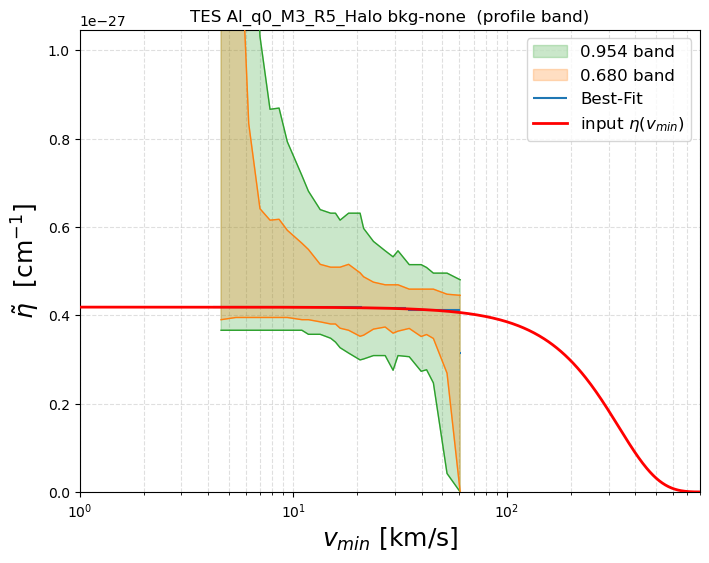

In [6]:
show_saved(eta='Halo');
# show_saved(eta='Disk');
# show_saved(disk_fraction=0.05);
# show_saved(disk_fraction=0.25);
# show_saved(eta='Bound');
